DAY 6 - WATER POTABILITY ANALYSIS


Saving water_potability.csv to water_potability (1).csv

First 5 Rows
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

Dataset Shape
(3276, 10)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Rang

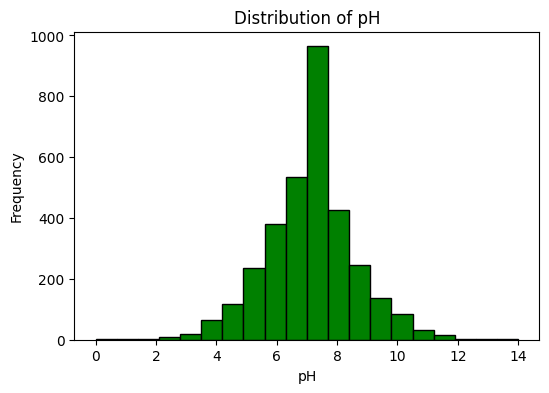

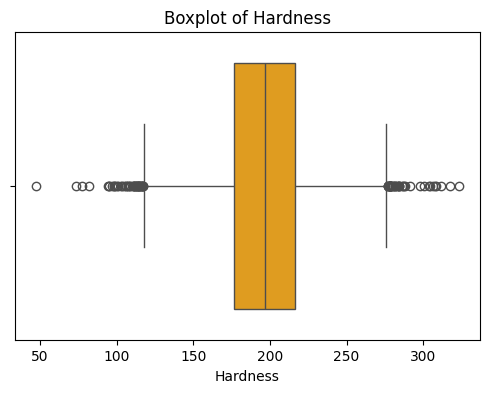

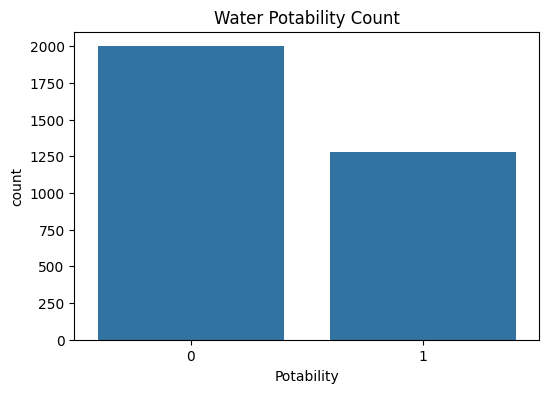

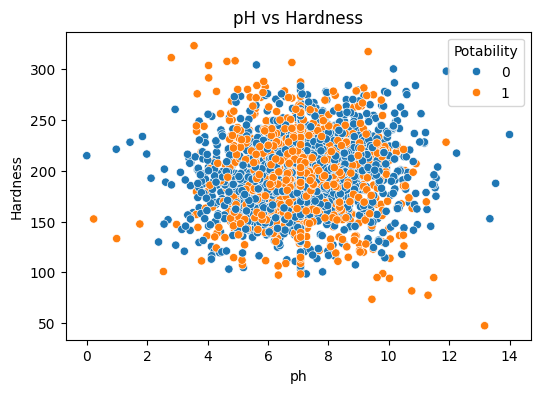

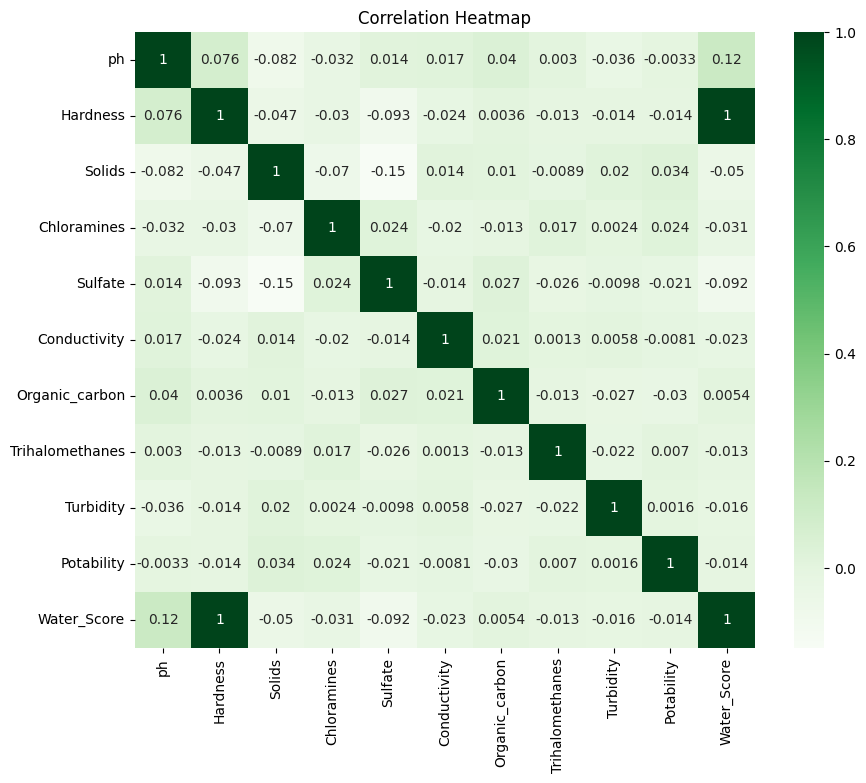

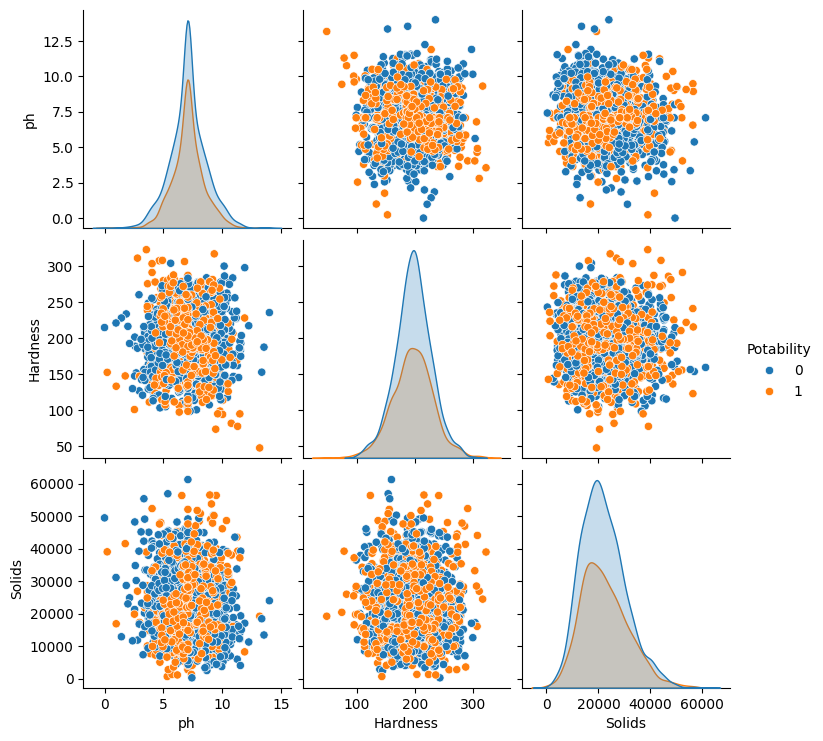

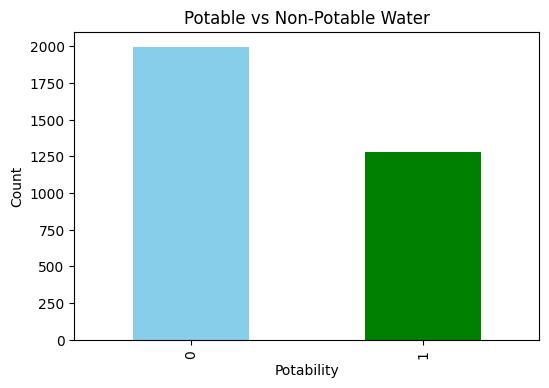


Visualization Completed Successfully!

Preparing Data for Machine Learning...
Training Data Shape : (2620, 10)
Testing Data Shape  : (656, 10)

Model Training Completed!

MODEL ACCURACY
Accuracy : 67.68 %

Confusion Matrix
[[365  47]
 [165  79]]


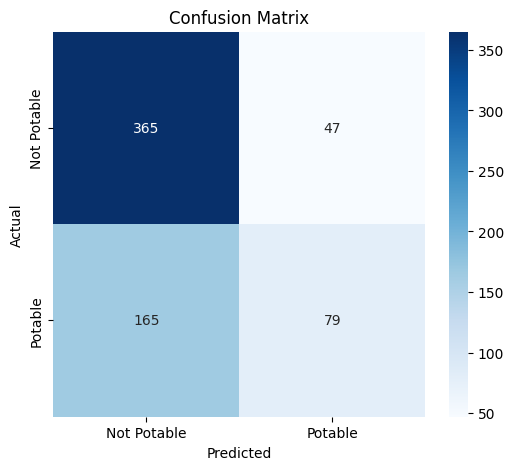


Classification Report
              precision    recall  f1-score   support

           0       0.69      0.89      0.77       412
           1       0.63      0.32      0.43       244

    accuracy                           0.68       656
   macro avg       0.66      0.60      0.60       656
weighted avg       0.67      0.68      0.65       656


Feature Importance
           Feature  Importance
0               ph    0.116333
4          Sulfate    0.115574
3      Chloramines    0.108195
2           Solids    0.106091
5     Conductivity    0.095400
1         Hardness    0.094019
6   Organic_carbon    0.092332
7  Trihalomethanes    0.091984
9      Water_Score    0.090758
8        Turbidity    0.089314


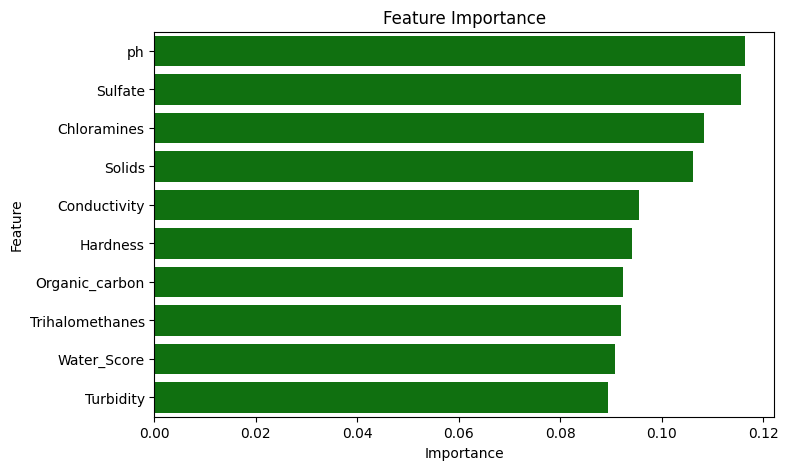


First 10 Predictions
   Actual  Predicted
0       0          0
1       1          0
2       0          0
3       0          0
4       1          0
5       1          1
6       0          1
7       0          1
8       0          1
9       0          0

PROJECT COMPLETED SUCCESSFULLY

Conclusion

1. The water potability dataset was loaded successfully.
2. Missing values were handled using mean values.
3. A new feature called Water_Score was created.
4. Different visualizations were used to understand the dataset.
5. A Random Forest Classifier was trained.
6. The model predicted whether water is safe to drink.
7. Accuracy, Confusion Matrix, and Classification Report were generated.

This project shows how Python and Machine Learning can be used to analyze water quality data.



In [3]:
# ==========================
# DAY 6 GTU INTERNSHIP TASK
# Water Potability Prediction
# ==========================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("="*50)
print("DAY 6 - WATER POTABILITY ANALYSIS")
print("="*50)

# Load Dataset
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("water_potability.csv")   # Use the exact uploaded filename

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values Before Cleaning")
print(df.isnull().sum())

# Fill Missing Values
df["ph"] = df["ph"].fillna(df["ph"].mean())
df["Sulfate"] = df["Sulfate"].fillna(df["Sulfate"].mean())
df["Trihalomethanes"] = df["Trihalomethanes"].fillna(df["Trihalomethanes"].mean())

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# Feature Engineering
df["Water_Score"] = (df["ph"] + df["Hardness"]) / 2

print("\nDataset After Feature Engineering")
print(df.head())

print("\nColumns")
print(df.columns)

print("\nCorrelation Matrix")
print(df.corr())

# ==========================
# DATA VISUALIZATION
# ==========================

# Histogram
plt.figure(figsize=(6,4))
plt.hist(df["ph"], bins=20, color="green", edgecolor="black")
plt.title("Distribution of pH")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Hardness"], color="orange")
plt.title("Boxplot of Hardness")
plt.show()

# Countplot
plt.figure(figsize=(6,4))
sns.countplot(x="Potability", data=df)
plt.title("Water Potability Count")
plt.show()

# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="ph",
    y="Hardness",
    hue="Potability",
    data=df
)
plt.title("pH vs Hardness")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="Greens")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(
    df[["ph", "Hardness", "Solids", "Potability"]],
    hue="Potability"
)
plt.show()

# Bar Chart
plt.figure(figsize=(6,4))
df["Potability"].value_counts().plot(kind="bar", color=["skyblue", "green"])
plt.title("Potable vs Non-Potable Water")
plt.xlabel("Potability")
plt.ylabel("Count")
plt.show()

print("\nVisualization Completed Successfully!")

# ==========================
# MACHINE LEARNING
# ==========================

print("\nPreparing Data for Machine Learning...")

# Features and Target
X = df.drop("Potability", axis=1)
y = df["Potability"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

# Create Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

print("\nModel Training Completed!")

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("MODEL ACCURACY")
print("==============================")
print("Accuracy :", round(accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Potable", "Potable"],
    yticklabels=["Not Potable", "Potable"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    color="green"
)
plt.title("Feature Importance")
plt.show()

# Sample Predictions
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nFirst 10 Predictions")
print(results.head(10))

print("\n==============================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("==============================")

print("""
Conclusion

1. The water potability dataset was loaded successfully.
2. Missing values were handled using mean values.
3. A new feature called Water_Score was created.
4. Different visualizations were used to understand the dataset.
5. A Random Forest Classifier was trained.
6. The model predicted whether water is safe to drink.
7. Accuracy, Confusion Matrix, and Classification Report were generated.

This project shows how Python and Machine Learning can be used to analyze water quality data.
""")